In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [4]:
data = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [5]:
def prepare_telco_df(df):
    """
    Preprocesses the Telco Customer Churn DataFrame.

    Args:
        df (pd.DataFrame): Raw Telco customer churn DataFrame.

    Returns:
        pd.DataFrame: Cleaned and preprocessed DataFrame ready for modeling.
    """
    
    # Drop unnecessary columns
    if 'customerID' in df.columns:
        df = df.drop('customerID', axis=1)
    
    # Convert TotalCharges to numeric and fill missing values
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'] = df['TotalCharges'].fillna(0)
    
    # Binary encoding for Yes/No columns
    binary_cols = ['Partner', 'Dependents', 'PaperlessBilling', 'Churn', 'PhoneService']
    df[binary_cols] = df[binary_cols].map(lambda x: 1 if x == 'Yes' else 0)
    
    # Encode gender
    df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})
    
    # Encode MultipleLines
    df['MultipleLines'] = df['MultipleLines'].map({'No phone service': 0, 'No': 0, 'Yes': 1})
    
    # Encode service-related columns
    service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                    'TechSupport', 'StreamingTV', 'StreamingMovies']
    df[service_cols] = df[service_cols].map(lambda x: 1 if x == 'Yes' else 0)
    
    # One-hot encode categorical columns
    categorical_cols = ['InternetService', 'Contract', 'PaymentMethod']
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    
    return df

In [6]:
data = prepare_telco_df(data)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   MultipleLines                          7043 non-null   int64  
 7   OnlineSecurity                         7043 non-null   int64  
 8   OnlineBackup                           7043 non-null   int64  
 9   DeviceProtection                       7043 non-null   int64  
 10  TechSupport                            7043 non-null   int64  
 11  Stre

In [8]:
data.isnull().sum()

gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
MultipleLines                            0
OnlineSecurity                           0
OnlineBackup                             0
DeviceProtection                         0
TechSupport                              0
StreamingTV                              0
StreamingMovies                          0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
InternetService_Fiber optic              0
InternetService_No                       0
Contract_One year                        0
Contract_Two year                        0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Electronic check           0
PaymentMeth

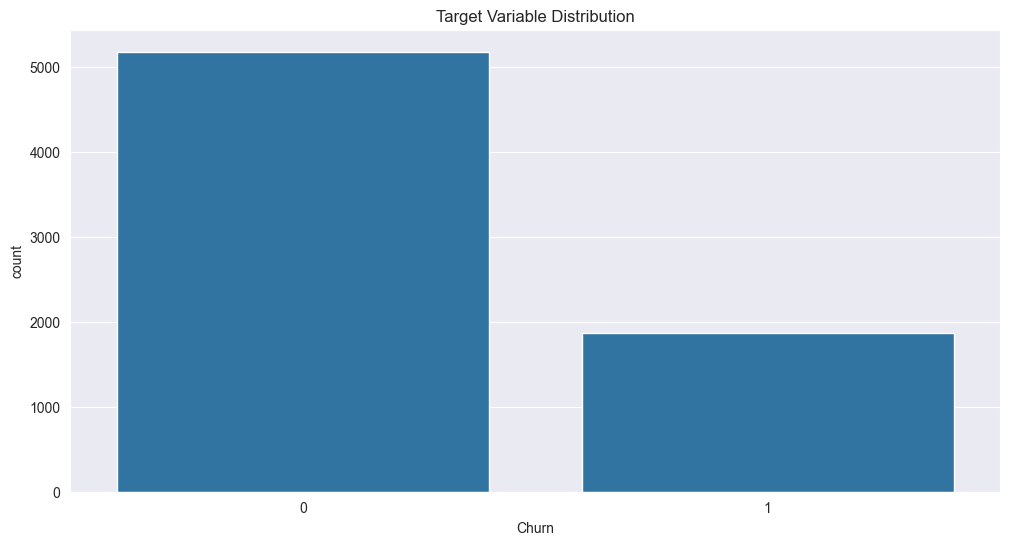

In [9]:
# DISTRIBUTION OF TARGET VARIABLE CLASSES
sns.set_style('darkgrid')
plt.figure(figsize=(12, 6))
sns.countplot(x = 'Churn', data = data)
plt.title('Target Variable Distribution')
plt.show()

the dataset is imbalanced l will apply and test several balancing techniques to ensure that the data is balanced( will test several hybrid data level techniques to avoid noise and class overlap during interpolation)

In [10]:
from collections import Counter
print(Counter(data.Churn))

Counter({0: 5174, 1: 1869})


In [11]:

### LETS CALCULATE THE IMBALANCED RATIO TO SEE THE DEGREE OF IMBALANCE
## IR =(NUMBER OF MAJORTY CLASS INSTANCES)/(NUMBER OF MINORITY CLASS INSTANCES)
IR = 5174/1869
print(IR)

2.7683253076511503


In [12]:
X = data.drop('Churn', axis=1)
y = data[['Churn']]

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler,OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
import random
SEED =2024
random.seed(SEED)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, cross_validate
from collections import Counter
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
from imblearn.over_sampling import SMOTENC
from scipy import stats
from sklearn.metrics import roc_curve, auc, precision_recall_curve, f1_score, roc_auc_score, make_scorer, confusion_matrix
from imblearn.metrics import sensitivity_score,specificity_score
from sklearn.model_selection import cross_val_score, cross_validate
from collections import Counter
import scipy.stats as stat
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import random
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score,accuracy_score,f1_score, cohen_kappa_score
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.svm import SVC
from collections import Counter
from sklearn.model_selection import train_test_split
import os
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold
import pickle
from imblearn.pipeline import Pipeline, make_pipeline

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2025, stratify = y)

To balance the two classes in the data 3 methods were compared


1. SMOTEENN >>> This technique is used because it contributes to comprehensive data cleaning. Here, further examples from both classes are removed to ensure noise reduction caused by SMOTE.
2. ADASYN >>> It adaptively modifies the sampling density based on the difficulty of learning regions and producing synthetic samples in places where the minority class is underrepresented, therefore making it better than SMOTE

In [15]:
#### lets apply smote-enn
from imblearn.combine import SMOTEENN
samp_pipeline = SMOTEENN(random_state=42)
X_S_ENN, y_S_ENN = samp_pipeline.fit_resample(X_train, y_train)

In [16]:
y

,Churn
0,0
1,0
2,1
3,0
4,1
...,...
7038,0
7039,0
7040,0
7041,1


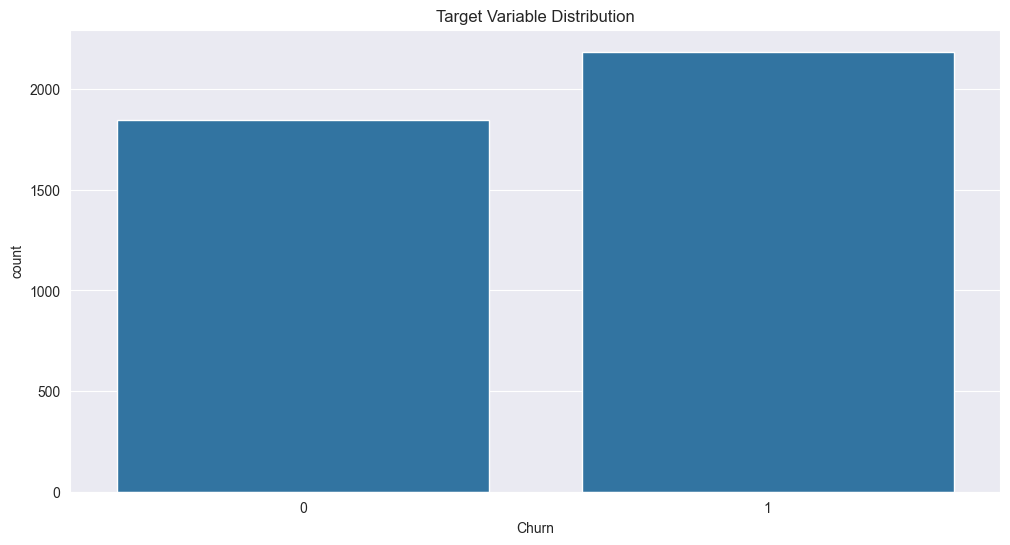

In [17]:
# DISTRIBUTION OF TARGET VARIABLE CLASSES
sns.set_style('darkgrid')
plt.figure(figsize=(12, 6))
sns.countplot(x = 'Churn', data = y_S_ENN)
plt.title('Target Variable Distribution')
plt.show()

In [18]:
####lets apply adasyn

from imblearn.over_sampling import ADASYN
ada = ADASYN(random_state=42)
X_res, y_res = ada.fit_resample(X_train, y_train)

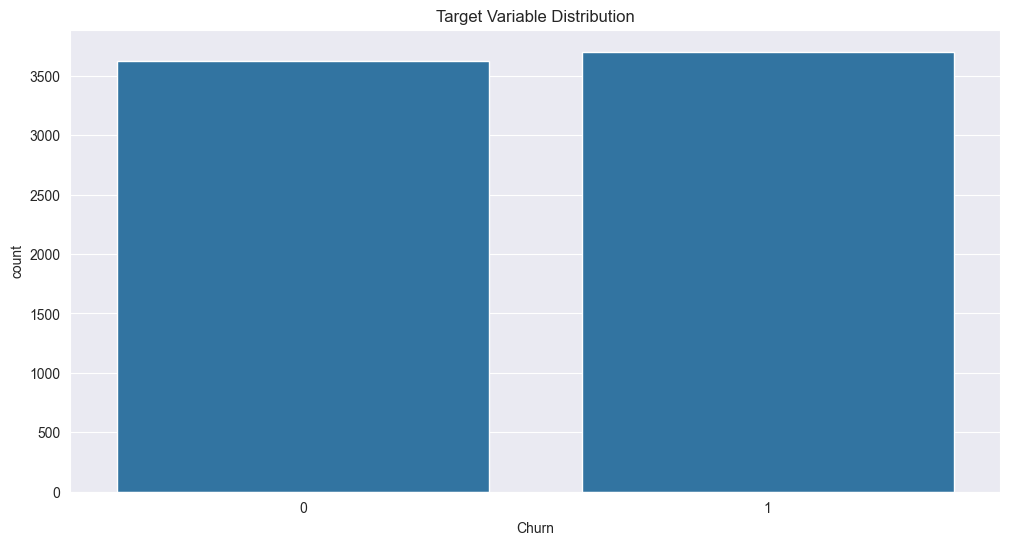

In [19]:
# DISTRIBUTION OF TARGET VARIABLE CLASSES
sns.set_style('darkgrid')
plt.figure(figsize=(12, 6))
sns.countplot(x = 'Churn', data = y_res)
plt.title('Target Variable Distribution')
plt.show()

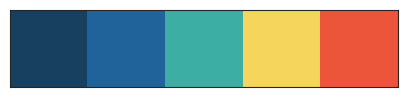

In [20]:
####### lets check for consistency of the methods
from tqdm import tqdm

# Modelling
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, accuracy_score, roc_auc_score
from sklearn import metrics


sns.set_style("white")

### Define the colour scheme
c1 = "#173f5f"
c2 = "#20639b"
c3 = "#3caea3"
c4 = "#f6d55c"
c5 = "#ed553b"

custom_palette = [c1, c2, c3, c4, c5]
sns.palplot(sns.color_palette(custom_palette))

In [21]:
####smote-enn

for sample_frac in tqdm(np.arange(20, 105, 5)):
    
    sampling_strategy = sample_frac/100
    train_data = RandomForestClassifier()
    clf = train_data.fit(X_S_ENN, y_S_ENN)
    
    # Make predictions
    y_pred = clf.predict(X_test)
    y_pred_bin = (y_pred > 0.5).astype("int")

    # Calculate ROC AUC score
    roc_auc = metrics.roc_auc_score(y_test, y_pred)
    f1_score = metrics.f1_score(y_test, y_pred_bin)
    precision_score = metrics.precision_score(y_test, y_pred_bin)
    recall_score = metrics.recall_score(y_test, y_pred_bin)

    if sample_frac == 20:
        df_result_enn = pd.DataFrame({'frac': [sampling_strategy], 'roc': [roc_auc], 'f1': [f1_score], 'precision': [precision_score], 'recall': [recall_score]})
    else:
        df_tmp = pd.DataFrame({'frac': [sampling_strategy], 'roc': [roc_auc], 'f1': [f1_score], 'precision': [precision_score], 'recall': [recall_score]})
        df_result_enn = pd.concat([df_result_enn, df_tmp], ignore_index=True, axis=0)
        
df_result_enn.head() 

100%|██████████| 17/17 [00:06<00:00,  2.45it/s]


,frac,roc,f1,precision,recall
0,0.20,0.757042,0.625564,0.540962,0.741533
1,0.25,0.755678,0.623318,0.536680,0.743316
2,0.30,0.754712,0.621924,0.534615,0.743316
3,0.35,0.752607,0.619403,0.532734,0.739750
4,0.40,0.758352,0.626398,0.538462,0.748663


In [22]:
####adasyn

for sample_frac in tqdm(np.arange(20, 105, 5)):
    
    sampling_strategy = sample_frac/100
    train_data = RandomForestClassifier()
    clf = train_data.fit(X_res, y_res)
    
    # Make predictions
    y_pred = clf.predict(X_test)
    y_pred_bin = (y_pred > 0.5).astype("int")

    # Calculate ROC AUC score
    roc_auc = metrics.roc_auc_score(y_test, y_pred)
    f1_score = metrics.f1_score(y_test, y_pred_bin)
    precision_score = metrics.precision_score(y_test, y_pred_bin)
    recall_score = metrics.recall_score(y_test, y_pred_bin)

    if sample_frac == 20:
        df_result_ada = pd.DataFrame({'frac': [sampling_strategy], 'roc': [roc_auc], 'f1': [f1_score], 'precision': [precision_score], 'recall': [recall_score]})
    else:
        df_tmp = pd.DataFrame({'frac': [sampling_strategy], 'roc': [roc_auc], 'f1': [f1_score], 'precision': [precision_score], 'recall': [recall_score]})
        df_result_ada = pd.concat([df_result_ada, df_tmp], ignore_index=True, axis=0)
        
df_result_ada.head() 

100%|██████████| 17/17 [00:14<00:00,  1.17it/s]


,frac,roc,f1,precision,recall
0,0.20,0.711643,0.575414,0.563140,0.588235
1,0.25,0.710978,0.574956,0.568935,0.581105
2,0.30,0.715681,0.581436,0.571429,0.591800
3,0.35,0.718087,0.585626,0.583039,0.588235
4,0.40,0.711794,0.575944,0.567474,0.584670


In [23]:
df_result_enn_rename = df_result_enn.copy()
df_result_ada_rename = df_result_ada.copy()
df_result_enn_rename = df_result_enn_rename.rename(columns={'roc':'roc_enn', 'f1':'f1_enn', 'precision':'precision_enn', 'recall':'recall_enn'})
df_result_ada_rename = df_result_ada_rename.rename(columns={'roc':'roc_ada', 'f1':'f1_ada', 'precision':'precision_ada', 'recall':'recall_ada'})

In [24]:
df_result = df_result_ada_rename.merge(df_result_enn_rename, on='frac', how='left')

df_result.head()

,frac,roc_ada,f1_ada,precision_ada,recall_ada,roc_enn,f1_enn,precision_enn,recall_enn
0,0.20,0.711643,0.575414,0.563140,0.588235,0.757042,0.625564,0.540962,0.741533
1,0.25,0.710978,0.574956,0.568935,0.581105,0.755678,0.623318,0.536680,0.743316
2,0.30,0.715681,0.581436,0.571429,0.591800,0.754712,0.621924,0.534615,0.743316
3,0.35,0.718087,0.585626,0.583039,0.588235,0.752607,0.619403,0.532734,0.739750
4,0.40,0.711794,0.575944,0.567474,0.584670,0.758352,0.626398,0.538462,0.748663


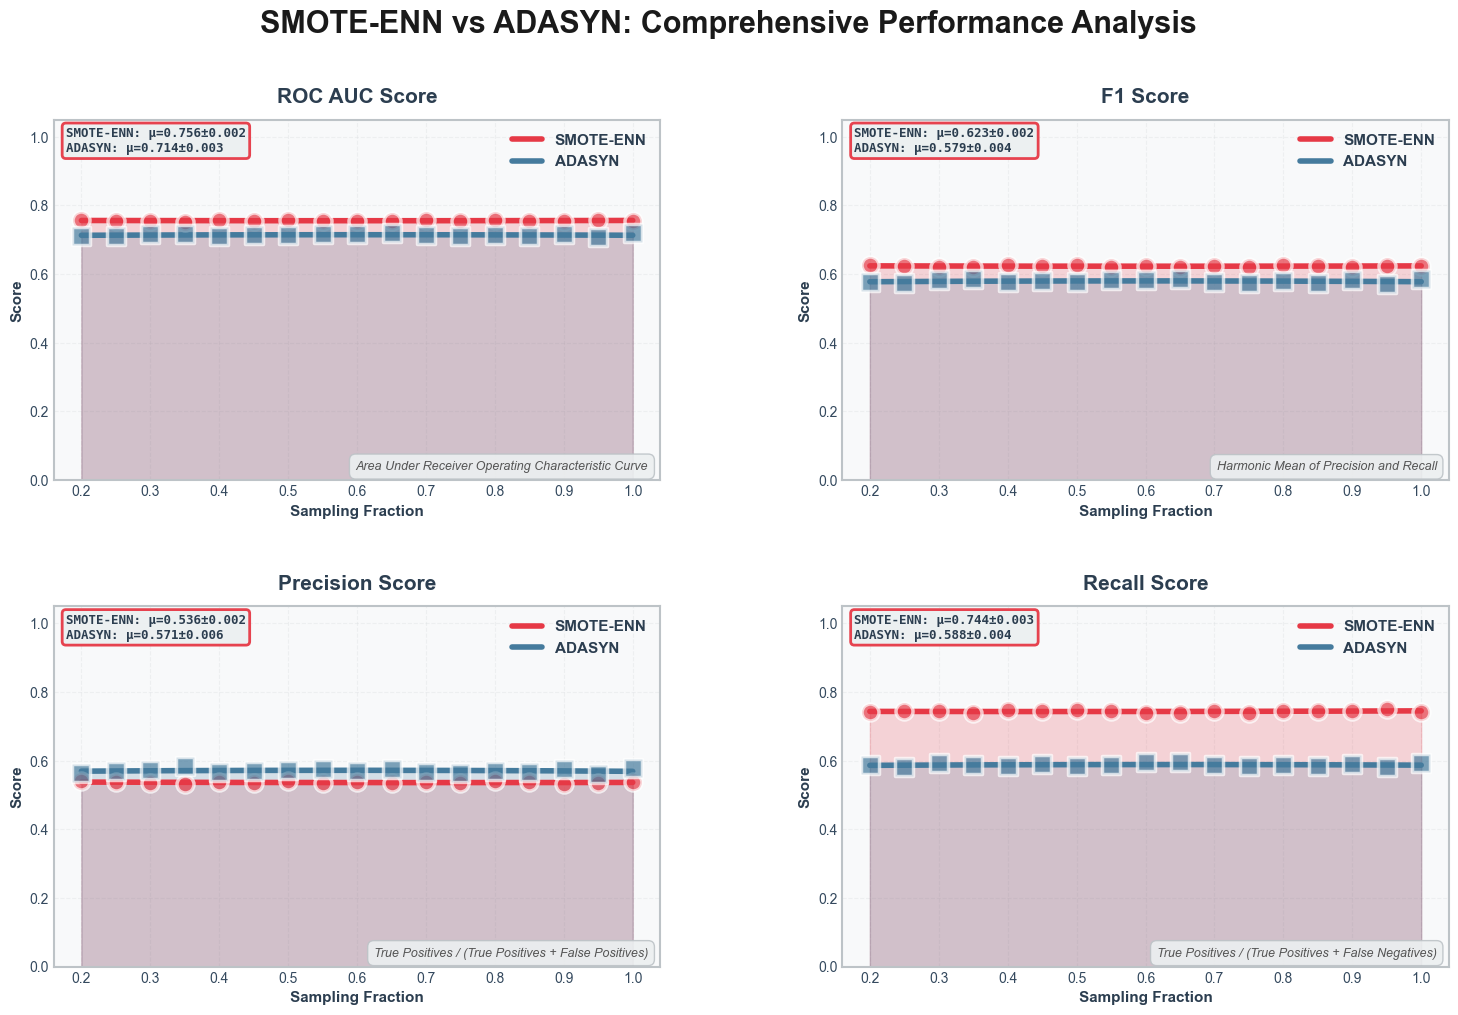

In [25]:
# Set professional light theme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Create figure with light background
fig = plt.figure(figsize=(18, 11))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)
fig.patch.set_facecolor('#ffffff')

# Title
fig.suptitle('SMOTE-ENN vs ADASYN: Comprehensive Performance Analysis', 
             fontsize=22, fontweight='bold', color='#1a1a1a', y=0.98)

# Modern color scheme
color_enn = '#E63946'  # Vibrant red
color_ada = '#457B9D'  # Professional blue
color_enn_fill = '#E6394620'  # Transparent red
color_ada_fill = '#457B9D20'  # Transparent blue

from scipy.ndimage import uniform_filter1d

metrics_config = [
    ('roc_enn', 'roc_ada', 'ROC AUC Score', 'Area Under Receiver Operating Characteristic Curve'),
    ('f1_enn', 'f1_ada', 'F1 Score', 'Harmonic Mean of Precision and Recall'),
    ('precision_enn', 'precision_ada', 'Precision Score', 'True Positives / (True Positives + False Positives)'),
    ('recall_enn', 'recall_ada', 'Recall Score', 'True Positives / (True Positives + False Negatives)')
]

for idx, (enn_col, ada_col, metric_name, metric_desc) in enumerate(metrics_config):
    ax = fig.add_subplot(gs[idx // 2, idx % 2])
    ax.set_facecolor('#f8f9fa')
    
    # Extract data for polynomial fitting
    x_data = df_result['frac'].values
    y_enn = df_result[enn_col].values
    y_ada = df_result[ada_col].values
    
    # Fit polynomials
    z_enn = np.polyfit(x_data, y_enn, 2)
    z_ada = np.polyfit(x_data, y_ada, 2)
    p_enn = np.poly1d(z_enn)
    p_ada = np.poly1d(z_ada)
    
    # Create smooth curve
    x_smooth = np.linspace(x_data.min(), x_data.max(), 300)
    y_enn_smooth = p_enn(x_smooth)
    y_ada_smooth = p_ada(x_smooth)
    
    # Plot filled areas under curves
    ax.fill_between(x_smooth, y_enn_smooth, alpha=0.2, color=color_enn, label='_nolegend_')
    ax.fill_between(x_smooth, y_ada_smooth, alpha=0.2, color=color_ada, label='_nolegend_')
    
    # Plot smooth lines
    ax.plot(x_smooth, y_enn_smooth, color=color_enn, linewidth=4, label='SMOTE-ENN', zorder=3)
    ax.plot(x_smooth, y_ada_smooth, color=color_ada, linewidth=4, label='ADASYN', zorder=3)
    
    # Plot scatter points with enhanced markers
    ax.scatter(x_data, y_enn, color=color_enn, s=150, marker='o', alpha=0.7, 
              edgecolors='white', linewidth=2.5, zorder=4, label='_nolegend_')
    ax.scatter(x_data, y_ada, color=color_ada, s=150, marker='s', alpha=0.7,
              edgecolors='white', linewidth=2.5, zorder=4, label='_nolegend_')
    
    # Calculate statistics
    enn_mean = y_enn.mean()
    ada_mean = y_ada.mean()
    enn_std = y_enn.std()
    ada_std = y_ada.std()
    
    # Enhanced title and labels
    ax.set_title(metric_name, fontsize=15, fontweight='bold', color='#2c3e50', pad=12)
    ax.text(0.98, 0.02, metric_desc, transform=ax.transAxes, fontsize=9, 
           style='italic', color='#555555', ha='right', va='bottom',
           bbox=dict(boxstyle='round,pad=0.5', facecolor='#ecf0f1', alpha=0.9, edgecolor='#bdc3c7', linewidth=1))
    
    ax.set_xlabel('Sampling Fraction', fontsize=11, fontweight='bold', color='#2c3e50')
    ax.set_ylabel('Score', fontsize=11, fontweight='bold', color='#2c3e50')
    
    # Grid styling
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8, color='#d5d8dc')
    
    # Axes styling
    ax.set_ylim([0, 1.05])
    ax.tick_params(colors='#34495e', labelsize=10)
    for spine in ax.spines.values():
        spine.set_color('#bdc3c7')
        spine.set_linewidth(1.5)
    
    # Statistics box
    stats_text = f'SMOTE-ENN: μ={enn_mean:.3f}±{enn_std:.3f}\nADASYN: μ={ada_mean:.3f}±{ada_std:.3f}'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
           verticalalignment='top', family='monospace', color='#2c3e50', fontweight='bold',
           bbox=dict(boxstyle='round', facecolor='#ecf0f1', edgecolor=color_enn, alpha=0.95, linewidth=2))
    
    # Enhanced legend
    legend = ax.legend(fontsize=11, loc='upper right', framealpha=0.98, 
                      edgecolor='#bdc3c7', fancybox=True, shadow=True)
    legend.get_frame().set_facecolor('#ffffff')
    for text in legend.get_texts():
        text.set_color('#2c3e50')
        text.set_fontweight('bold')

plt.tight_layout()
plt.show()


based on the results SMOTEENN performs better than ADASYN in all the metrics and it is more consistent, and hence we will go ahead with SMOTEENN for further model building and hyperparameter tuning.  

### HYPERPARAMETER TUNING

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

RF = RandomForestClassifier(
    random_state=42
)

param_grid = {

    # Split quality
    'criterion': ['entropy'],

    # Forest size
    'n_estimators': [100, 200, 300],

    # Tree structure
    'max_depth': [None, 10, 20, 30],
    'max_leaf_nodes': [None, 20, 30, 50],

    # Sample constraints
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5, 10],

    # Feature randomness
    'max_features': ['sqrt', 'log2', None],

    # Bagging
    'bootstrap': [True]}

grid_search = GridSearchCV(
    estimator=RF,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1,
    scoring='f1'
)

grid_search.fit(X_S_ENN, y_S_ENN)

grid_search.best_params_


Fitting 3 folds for each of 1728 candidates, totalling 5184 fits


{'bootstrap': True,
 'criterion': 'entropy',
 'max_depth': 20,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 200}

In [27]:
grid_search.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

In [35]:
## fitting the model with best parameters 

# returns the model performance for {evaluation} in terms of accuracy, classification report and the confusion matrix
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

def model_performance(y_test, y_pred, y_pred_proba, model, method):
    """
    Comprehensive model performance evaluation with beautiful visualizations.
    
    Parameters:
    -----------
    y_test : array-like
        True labels
    y_pred : array-like
        Predicted labels
    y_pred_proba : array-like
        Predicted probabilities
    model : sklearn model
        Trained model (for feature importance)
    method : str
        Name of the model
    """
    
    from sklearn.metrics import roc_curve, precision_recall_curve, auc
    from scipy.stats import gmean as scipy_gmean
    
    # Calculate metrics
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_pred_proba)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    sensitivity = sensitivity_score(y_test, y_pred)
    specificity = specificity_score(y_test, y_pred)
    
    # Calculate G-Mean metric
    gmean = scipy_gmean([sensitivity, specificity])
    
    # Calculate PRAUC
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
    prauc = auc(recall_vals, precision_vals)
    
    # Print metrics in a formatted way
    print(f"\n{'='*60}")
    print(f"MODEL PERFORMANCE METRICS: {method}".center(60))
    print(f"{'='*60}\n")
    
    metrics_display = [
        ("Balanced Accuracy", bal_acc),
        ("AUC (ROC)", auc_score),
        ("PRAUC (PR)", prauc),
        ("Precision", precision),
        ("Recall/Sensitivity", recall),
        ("Specificity", specificity),
        ("G-Mean", gmean),
        ("F1 Score", f1)
    ]
    
    for metric_name, metric_value in metrics_display:
        print(f"{metric_name:.<40} {metric_value:.4f}")
    
    print(f"\n{'='*60}")
    print("CLASSIFICATION REPORT\n")
    print(classification_report(y_test, y_pred))
    print(f"{'='*60}\n")
    
    # Create comprehensive visualization
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)
    
    # Color palette
    color_primary = '#2E86AB'
    color_secondary = '#A23B72'
    color_success = '#06A77D'
    color_warning = '#F18F01'
    
    # 1. Confusion Matrix (Top Left)
    ax1 = fig.add_subplot(gs[0, 0])
    cnf_matrix = confusion_matrix(y_test, y_pred)
    sns.heatmap(cnf_matrix, annot=True, fmt='d', cmap='Blues', 
                cbar_kws={'label': 'Count'}, ax=ax1, 
                annot_kws={'fontsize': 12, 'fontweight': 'bold'})
    ax1.set_title(f'Confusion Matrix\n{method}', fontsize=12, fontweight='bold', pad=10)
    ax1.set_ylabel('True Label', fontweight='bold')
    ax1.set_xlabel('Predicted Label', fontweight='bold')
    
    # 2. ROC Curve (Top Middle)
    ax2 = fig.add_subplot(gs[0, 1])
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    ax2.plot(fpr, tpr, color=color_primary, lw=3, 
             label=f'ROC Curve (AUC = {auc_score:.4f})')
    ax2.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.3, label='Random Classifier')
    ax2.fill_between(fpr, tpr, alpha=0.2, color=color_primary)
    ax2.set_xlabel('False Positive Rate', fontweight='bold')
    ax2.set_ylabel('True Positive Rate', fontweight='bold')
    ax2.set_title('ROC Curve', fontsize=12, fontweight='bold', pad=10)
    ax2.legend(loc='lower right', fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    # 3. Precision-Recall Curve (Top Right)
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.plot(recall_vals, precision_vals, color=color_secondary, lw=3,
             label=f'PR Curve (PRAUC = {prauc:.4f})')
    ax3.fill_between(recall_vals, precision_vals, alpha=0.2, color=color_secondary)
    ax3.set_xlabel('Recall', fontweight='bold')
    ax3.set_ylabel('Precision', fontweight='bold')
    ax3.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold', pad=10)
    ax3.legend(loc='best', fontsize=10)
    ax3.grid(True, alpha=0.3)
    
    # 4. Feature Importance (Middle Left - spans 2 rows)
    ax4 = fig.add_subplot(gs[1:, 0])
    if hasattr(model, 'feature_importances_'):
        feature_importance = pd.DataFrame({
            'Feature': X_train.columns,
            'Importance': model.feature_importances_
        }).sort_values('Importance', ascending=True).tail(15)
        
        colors_gradient = plt.cm.viridis(np.linspace(0.3, 0.9, len(feature_importance)))
        bars = ax4.barh(feature_importance['Feature'], feature_importance['Importance'], 
                        color=colors_gradient, edgecolor='black', linewidth=1.2)
        ax4.set_xlabel('Importance Score', fontweight='bold', fontsize=11)
        ax4.set_title('Top 15 Feature Importance', fontsize=12, fontweight='bold', pad=10)
        ax4.grid(axis='x', alpha=0.3)
        
        # Add value labels
        for i, bar in enumerate(bars):
            width = bar.get_width()
            ax4.text(width, bar.get_y() + bar.get_height()/2, 
                    f'{width:.4f}', ha='left', va='center', fontsize=9, fontweight='bold')
    
    # 5. Metrics Comparison (Middle Center)
    ax5 = fig.add_subplot(gs[1, 1])
    metrics_names = ['Precision', 'Recall', 'Specificity', 'F1', 'G-Mean', 'AUC']
    metrics_values = [precision, recall, specificity, f1, gmean, auc_score]
    colors_metrics = [color_primary, color_secondary, color_warning, color_success, '#F78C6B', '#C73E1D']
    
    bars = ax5.bar(range(len(metrics_names)), metrics_values, 
                   color=colors_metrics, edgecolor='black', linewidth=1.5, alpha=0.85)
    ax5.set_ylabel('Score', fontweight='bold', fontsize=11)
    ax5.set_title('Performance Metrics Comparison', fontsize=12, fontweight='bold', pad=10)
    ax5.set_xticks(range(len(metrics_names)))
    ax5.set_xticklabels(metrics_names, rotation=45, ha='right', fontsize=9)
    ax5.set_ylim([0, 1.05])
    ax5.grid(axis='y', alpha=0.3)
    ax5.axhline(y=0.5, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Baseline')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 6. Sensitivity vs Specificity (Middle Right)
    ax6 = fig.add_subplot(gs[1, 2])
    sens_spec_data = [sensitivity, specificity]
    sens_spec_labels = ['Sensitivity\n(Recall)', 'Specificity']
    colors_ss = [color_primary, color_secondary]
    
    bars = ax6.bar(sens_spec_labels, sens_spec_data, color=colors_ss, 
                   edgecolor='black', linewidth=1.5, alpha=0.85, width=0.6)
    ax6.set_ylabel('Score', fontweight='bold', fontsize=11)
    ax6.set_title('Sensitivity vs Specificity', fontsize=12, fontweight='bold', pad=10)
    ax6.set_ylim([0, 1.05])
    ax6.grid(axis='y', alpha=0.3)
    
    for bar in bars:
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # 7. Key Metrics Summary (Bottom Center)
    ax7 = fig.add_subplot(gs[2, 1])
    ax7.axis('off')
    
    summary_text = f"""
    MODEL: {method}
    
    ★ Overall Performance
    Balanced Accuracy:  {bal_acc:.4f}
    
    ★ Classification Quality
    AUC (ROC):          {auc_score:.4f}
    PRAUC (PR):         {prauc:.4f}
    F1 Score:           {f1:.4f}
    
    ★ Balance Metric
    G-Mean:             {gmean:.4f}
    """
    
    ax7.text(0.1, 0.5, summary_text, fontsize=11, verticalalignment='center',
            family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
            fontweight='bold')
    
    # 8. Classification Distribution (Bottom Right)
    ax8 = fig.add_subplot(gs[2, 2])
    class_dist = pd.Series(y_pred).value_counts().sort_index()
    colors_dist = [color_success, color_warning]
    wedges, texts, autotexts = ax8.pie(class_dist, labels=['No Churn', 'Churn'],
                                        autopct='%1.1f%%', colors=colors_dist,
                                        startangle=90, textprops={'fontweight': 'bold', 'fontsize': 10})
    ax8.set_title('Prediction Distribution', fontsize=12, fontweight='bold', pad=10)
    
    # Make percentage text more readable
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(11)
    
    plt.suptitle(f'{method} - Comprehensive Model Performance Analysis', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    plt.show()
    
    return {
        'balanced_accuracy': bal_acc,
        'auc': auc_score,
        'prauc': prauc,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'gmean': gmean,
        'f1': f1
    }

In [36]:
RF_final = RandomForestClassifier(bootstrap=True,
                                  criterion='entropy',
                                  max_depth=20,
                                  max_features='sqrt',
                                  max_leaf_nodes=None,
                                  min_samples_leaf=2,
                                  min_samples_split=2,
                                  n_estimators=200)

RF_final.fit(X_S_ENN, y_S_ENN)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri


          MODEL PERFORMANCE METRICS: Random Forest          

Balanced Accuracy....................... 0.7586
AUC (ROC)............................... 0.8340
PRAUC (PR).............................. 0.6330
Precision............................... 0.5377
Recall/Sensitivity...................... 0.7504
Specificity............................. 0.7668
G-Mean.................................. 0.7586
F1 Score................................ 0.6265

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.89      0.77      0.83      1552
           1       0.54      0.75      0.63       561

    accuracy                           0.76      2113
   macro avg       0.72      0.76      0.73      2113
weighted avg       0.80      0.76      0.77      2113




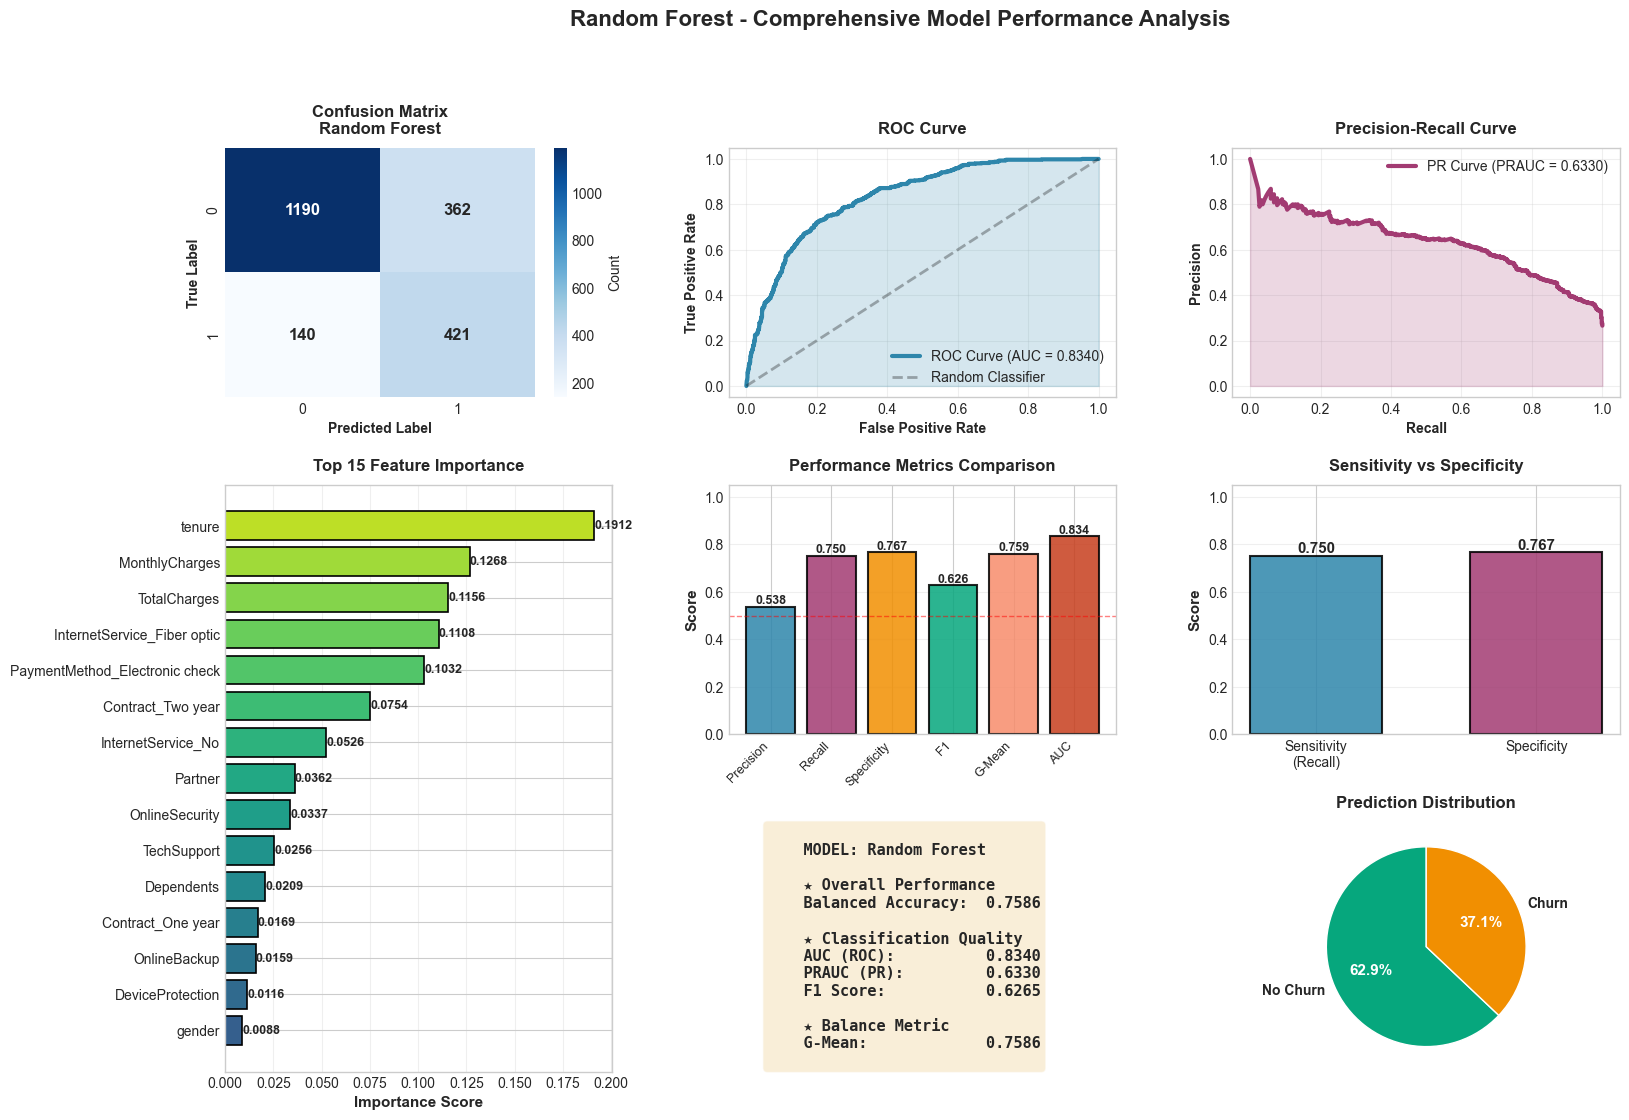

{'balanced_accuracy': 0.7585991050590808,
 'auc': 0.8339713462704671,
 'prauc': 0.6329595095072242,
 'precision': 0.5376756066411239,
 'recall': 0.750445632798574,
 'specificity': np.float64(0.7667525773195877),
 'gmean': np.float64(0.7585552867698804),
 'f1': 0.6264880952380952}

In [37]:
### Evaluating the random forest model on test data
RF_preds =  RF_final.predict(X_test)
RF_preds_proba = RF_final.predict_proba(X_test)[:, 1]  # Get probabilities for positive class
# measure the model performance
model_performance(y_test, RF_preds, RF_preds_proba, RF_final, 'Random Forest')

In [38]:
### SAVING THE MODEL
import pickle

pickle.dump(RF_final, open('model.pkl','wb'))

## MODEL EXPLANABILITY 

In [40]:
import eli5
from eli5.sklearn import PermutationImportance

from pdpbox import pdp, info_plots

In [43]:
perm = PermutationImportance(RF_final, random_state=2026).fit(X_test, y_test)
eli5.show_weights(perm, feature_names = X_test.columns.tolist())

Weight,Feature
0.0380 ± 0.0088,tenure
0.0071 ± 0.0049,TotalCharges
0.0065 ± 0.0089,MonthlyCharges
0.0049 ± 0.0028,OnlineSecurity
0.0042 ± 0.0047,PaymentMethod_Electronic check
0.0041 ± 0.0014,InternetService_No
0.0036 ± 0.0019,gender
0.0031 ± 0.0015,PaymentMethod_Credit card (automatic)
0.0028 ± 0.0006,DeviceProtection
0.0027 ± 0.0031,TechSupport
